In [2]:
import pandas as pd
df = pd.read_parquet('../data/raw/f1_all.parquet')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69230 entries, 0 to 69229
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         69230 non-null  int64  
 1   driverId       69230 non-null  int64  
 2   lap            69230 non-null  int64  
 3   position_x     69230 non-null  int64  
 4   time           69230 non-null  str    
 5   milliseconds   69230 non-null  int64  
 6   year           69230 non-null  int64  
 7   round          69230 non-null  int64  
 8   circuitId      69230 non-null  int64  
 9   name           69230 non-null  str    
 10  position_y     69155 non-null  float64
 11  grid           69230 non-null  str    
 12  constructorId  69230 non-null  int64  
 13  statusId       69230 non-null  int64  
 14  status         69230 non-null  str    
 15  code           69230 non-null  str    
 16  Driver         69230 non-null  str    
 17  LapNumber      69230 non-null  int64  
 18  Compound       69

In [4]:
df.shape

(69230, 29)

In [5]:
df.head()

,raceId,driverId,lap,position_x,time,milliseconds,year,round,circuitId,name,...,TyreLife,FreshTyre,Stint,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,1052,830,1,1,1:58.245,118245,2021,1,3,Bahrain International Circuit,...,4.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
1,1052,830,2,1,2:22.406,142406,2021,1,3,Bahrain International Circuit,...,5.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
2,1052,830,3,1,2:38.001,158001,2021,1,3,Bahrain International Circuit,...,6.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
3,1052,830,4,1,1:44.343,104343,2021,1,3,Bahrain International Circuit,...,7.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
4,1052,830,5,1,1:44.629,104629,2021,1,3,Bahrain International Circuit,...,8.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0


In [6]:
df['status'].unique()

<ArrowStringArray>
[        'Finished',          'Retired',           'Brakes',
           '+1 Lap',        'Collision',          '+2 Laps',
          'Gearbox', 'Collision damage',       'Electrical',
        'Wheel nut',          '+3 Laps',         'Accident',
            'Turbo',           'Engine',     'Disqualified',
       'Power Unit',       'Hydraulics',       'Suspension',
         'Oil leak',       'Mechanical',        'Rear wing',
       'Power loss',           'Damage',         'Puncture',
    'Fuel pressure',       'Water pump',   'Cooling system',
        'Fuel leak',         'Spun off',       'Front wing',
       'Water leak',   'Water pressure',       'Vibrations',
        'Fuel pump',        'Undertray',          '+6 Laps',
     'Differential',      'Overheating',         'Steering',
        'Technical',          'Illness',         'Radiator',
         'Withdrew']
Length: 43, dtype: str

In [7]:
df['code'].unique()

<ArrowStringArray>
['VER', 'HAM', 'LEC', 'BOT', 'GAS', 'NOR', 'RIC', 'ALO', 'STR', 'SAI', 'RAI',
 'GIO', 'OCO', 'VET', 'TSU', 'RUS', 'LAT', 'MSC', 'PER', 'MAZ', 'KUB', 'MAG',
 'ALB', 'HUL', 'ZHO', 'DEV', 'SAR', 'PIA', 'LAW']
Length: 29, dtype: str

In [8]:
df['Driver'].unique()

<ArrowStringArray>
['VER', 'HAM', 'LEC', 'BOT', 'GAS', 'NOR', 'RIC', 'ALO', 'STR', 'SAI', 'RAI',
 'GIO', 'OCO', 'VET', 'TSU', 'RUS', 'LAT', 'MSC', 'PER', 'MAZ', 'KUB', 'MAG',
 'ALB', 'HUL', 'ZHO', 'DEV', 'SAR', 'PIA', 'LAW']
Length: 29, dtype: str

In [9]:
df['Compound'].unique()

<ArrowStringArray>
['MEDIUM', 'HARD', 'SOFT', 'INTERMEDIATE', 'WET', 'UNKNOWN', 'None']
Length: 7, dtype: str

In [10]:
df['Compound'].value_counts()

Compound
HARD            29668
MEDIUM          24965
SOFT             9869
INTERMEDIATE     3886
WET               454
None              368
UNKNOWN            20
Name: count, dtype: int64

Vou trocar o 'None' por 'Unknown', porque 'None' é resposta do Python a quando um valor é nulo, então seria o equivalente a 'Unknown'.

# Dicionário de Dados

## Race Info (Informações da Corrida)

| Indicador | Descrição |
|---|---|
| raceId | ID da corrida. |
| year | O ano da corrida. |
| round | O número da rodada da corrida dentro da temporada. |
| circuitId | ID do circuito. |
| name | Nome do circuito. |

---

## Driver & Lap Info (Informações do Piloto e da Volta)

| Indicador | Descrição |
|---|---|
| driverId | ID do piloto. |
| constructorId | ID da equipe (construtora) do piloto. |
| lap / LapNumber | O número da volta. |
| code / Driver | Código de três letras do piloto. |
| time | O tempo registrado para a volta convertido em número legível. |
| milliseconds | O tempo da volta em milissegundos. |
| status | Informa se o piloto terminou a corrida ou não. |
| statusId | ID do status do piloto. |
| position_x | Posição do piloto no eixo X, considerando um plano cartesiano. |
| position_y | Posição do piloto no eixo Y, considerando um plano cartesiano. |
| grid | A posição do piloto no grid de largada. |
| Stint | O número do stint (período entre trocas de pneus) do piloto. |

---

## Tyre Features (Características dos Pneus)

| Indicador | Descrição |
|---|---|
| Compound | O tipo de composto do pneu (SOFT, MEDIUM, HARD, INTERMEDIATE, WET). |
| TyreLife | Quantas voltas o pneu já rodou naquele stint. |
| FreshTyre | Indica se o pneu é novo (True) ou usado (False). |

---

## Weather Features (Características do Clima)

| Indicador | Descrição |
|---|---|
| TrackTemp | A temperatura da pista (°C). |
| AirTemp | A temperatura do ar (°C). |
| Humidity | A umidade relativa do ar (%). |
| Pressure | A pressão atmosférica (mbar). |
| Rainfall | Indica se havia chuva (booleano). |
| WindSpeed | A velocidade do vento (km/h). |
| WindDirection | A direção do vento (graus). |

---

## Target (Variável Alvo)

| Indicador | Descrição |
|---|---|
| pitstop_turn | Número da volta em que o piloto realizou o pit stop. Derivada como a última volta de cada stint, excluindo o stint final da corrida. |

---


**Objetivo:** Fazer um modelo que faça previsão de qual é a melhor volta para se fazer a troca de pneu (pit stop) na Fórmula 1.

**Perguntas pertinentes**
- O desgaste dos pneus (`TyreLife`) influencia o momento do pit stop?
- Diferentes compostos resultam em paradas em voltas diferentes?
- A temperatura da pista antecipa ou posterga a troca de pneu?
- Dados climáticos melhoram a previsão da volta de parada?
- O modelo generaliza para diferentes circuitos?

**Hipóteses**
- Pneus duros (HARD) permitem stints mais longos, resultando em pit stops mais tardios.
- Temperaturas de pista mais altas aceleram a degradação e antecipam a parada.
- Variáveis climáticas reduzem o erro do modelo.


## Dimensões do Dataset

O dataset bruto (`f1_all.parquet`) possui **69.230 linhas × 29 colunas**. Cada linha representa uma volta de um piloto em uma corrida. Para a modelagem, o dataset será agregado por stint — um registro por pit stop registrado.


# Pré-processamento dos dados

## **Tratamento de Dados**

Tratamento de nulos

In [11]:
df.isna().sum()

raceId             0
driverId           0
lap                0
position_x         0
time               0
milliseconds       0
year               0
round              0
circuitId          0
name               0
position_y        75
grid               0
constructorId      0
statusId           0
status             0
code               0
Driver             0
LapNumber          0
Compound           0
TyreLife         553
FreshTyre          0
Stint              0
AirTemp            0
TrackTemp          0
Humidity           0
Pressure           0
Rainfall           0
WindSpeed          0
WindDirection      0
dtype: int64

Dentre as variáveis interessantes de se explorar, TyreLife parece nos aproximar mais do objetivo, position_y é facilmente ignorável aqui.

In [12]:
df['TyreLife'].head()

0    4.0
1    5.0
2    6.0
3    7.0
4    8.0
Name: TyreLife, dtype: float64

In [13]:
df[df['TyreLife'].isna()][['raceId', 'driverId', 'code', 'status', 'statusId', 'time', 'Stint','FreshTyre']]

,raceId,driverId,code,status,statusId,time,Stint,FreshTyre
30103,1080,844,LEC,Finished,1,1:30.149,2.0,False
30104,1080,844,LEC,Finished,1,1:28.156,2.0,False
30105,1080,844,LEC,Finished,1,1:46.560,2.0,False
30170,1080,832,SAI,Finished,1,1:34.073,2.0,False
30171,1080,832,SAI,Finished,1,1:30.160,2.0,False
...,...,...,...,...,...,...,...,...
54070,1106,852,TSU,Finished,1,1:17.010,3.0,False
54071,1106,852,TSU,Finished,1,1:16.821,3.0,False
54072,1106,852,TSU,Finished,1,1:16.666,3.0,False
54073,1106,852,TSU,Finished,1,1:16.852,3.0,False


Há muitas sequências, estou desconfiada de que, para alguns casos pelo menos, é possível traçar uma contagem se o tipo de pneu for o mesmo e se é a primeira vez usando esse pneu.

In [14]:
df[
    (df['raceId'] == 1080) &
    (df['code'] == 'LEC') &
    (df['lap'] > 10) &
    (df['lap'] <= 25)
][[
    'raceId', 'driverId', 'code', 'status', 'statusId', 'lap',
    'time', 'Stint', 'Compound', 'TyreLife', 'FreshTyre'
]]

,raceId,driverId,code,status,statusId,lap,time,Stint,Compound,TyreLife,FreshTyre
30095,1080,844,LEC,Finished,1,11,1:35.323,1.0,WET,11.0,True
30096,1080,844,LEC,Finished,1,12,1:35.077,1.0,WET,12.0,True
30097,1080,844,LEC,Finished,1,13,1:33.665,1.0,WET,13.0,True
30098,1080,844,LEC,Finished,1,14,1:33.314,1.0,WET,14.0,True
30099,1080,844,LEC,Finished,1,15,1:32.098,1.0,WET,15.0,True
30100,1080,844,LEC,Finished,1,16,1:32.133,1.0,WET,16.0,True
30101,1080,844,LEC,Finished,1,17,1:31.490,1.0,WET,17.0,True
30102,1080,844,LEC,Finished,1,18,1:50.848,1.0,WET,18.0,True
30103,1080,844,LEC,Finished,1,19,1:30.149,2.0,INTERMEDIATE,NaN,False
30104,1080,844,LEC,Finished,1,20,1:28.156,2.0,INTERMEDIATE,NaN,False


Para esse caso ficou um pouco inconclusivo. Eu teria que ver mais casos onde a Ferrari já tenha usado pneu intermediário para ver se existem casos onde o pneu foi usado.

In [15]:
df[
    (df['raceId'] == 1080) &
    (df['code'] == 'SAI') &
    (df['lap'] > 18) &
    (df['lap'] <= 33)
][[
    'raceId', 'driverId', 'code', 'status', 'statusId', 'lap',
    'time', 'Stint', 'Compound', 'TyreLife', 'FreshTyre'
]]

,raceId,driverId,code,status,statusId,lap,time,Stint,Compound,TyreLife,FreshTyre
30167,1080,832,SAI,Finished,1,19,1:31.775,1.0,WET,19.0,True
30168,1080,832,SAI,Finished,1,20,1:31.651,1.0,WET,20.0,True
30169,1080,832,SAI,Finished,1,21,1:47.551,1.0,WET,21.0,True
30170,1080,832,SAI,Finished,1,22,1:34.073,2.0,HARD,NaN,False
30171,1080,832,SAI,Finished,1,23,1:30.160,2.0,HARD,NaN,False
30172,1080,832,SAI,Finished,1,24,1:26.153,2.0,HARD,NaN,False
30173,1080,832,SAI,Finished,1,25,1:22.698,2.0,HARD,NaN,False
30174,1080,832,SAI,Finished,1,26,1:23.624,2.0,HARD,NaN,False
30175,1080,832,SAI,Finished,1,27,1:58.132,2.0,HARD,NaN,False
30176,1080,832,SAI,Finished,1,28,2:06.778,2.0,HARD,NaN,False


Esse aqui combina com a minha suspeita: dá certinho da troca por pneu duro até a contagem 10 de idade do pneu do Sainz, por exemplo.

In [16]:
df[
    (df['raceId'] == 1080) &
    (df['code'] == 'BOT') &
    (df['lap'] > 17) &
    (df['lap'] <= 33)
][[
    'raceId', 'driverId', 'code', 'status', 'statusId', 'lap',
    'time', 'Stint', 'Compound', 'TyreLife', 'FreshTyre'
]]

,raceId,driverId,code,status,statusId,lap,time,Stint,Compound,TyreLife,FreshTyre
30805,1080,822,BOT,Finished,1,18,1:34.208,1.0,WET,18.0,True
30806,1080,822,BOT,Finished,1,19,1:32.732,1.0,WET,19.0,True
30807,1080,822,BOT,Finished,1,20,1:49.539,1.0,WET,20.0,True
30808,1080,822,BOT,Finished,1,21,1:35.899,2.0,HARD,NaN,False
30809,1080,822,BOT,Finished,1,22,1:29.113,2.0,HARD,NaN,False
30810,1080,822,BOT,Finished,1,23,1:27.400,2.0,HARD,NaN,False
30811,1080,822,BOT,Finished,1,24,1:25.597,2.0,HARD,NaN,False
30812,1080,822,BOT,Finished,1,25,1:24.056,2.0,HARD,NaN,False
30813,1080,822,BOT,Finished,1,26,1:50.905,2.0,HARD,NaN,False
30814,1080,822,BOT,Finished,1,27,1:54.094,2.0,HARD,NaN,False


Nesse do Bottas também dá para ver esse padrão.

In [17]:
df[
    (df['raceId'] == 1106) &
    (df['code'] == 'TSU') &
    (df['lap'] > 27) &
    (df['lap'] <= 51)
][[
    'raceId', 'driverId', 'code', 'status', 'statusId', 'lap',
    'time', 'Stint', 'Compound', 'TyreLife', 'FreshTyre'
]]

,raceId,driverId,code,status,statusId,lap,time,Stint,Compound,TyreLife,FreshTyre
54032,1106,852,TSU,Finished,1,28,1:18.426,2.0,HARD,27.0,True
54033,1106,852,TSU,Finished,1,29,1:18.779,2.0,HARD,28.0,True
54034,1106,852,TSU,Finished,1,30,1:18.493,2.0,HARD,29.0,True
54035,1106,852,TSU,Finished,1,31,1:18.383,2.0,HARD,30.0,True
54036,1106,852,TSU,Finished,1,32,1:18.732,2.0,HARD,31.0,True
54037,1106,852,TSU,Finished,1,33,1:18.852,2.0,HARD,32.0,True
54038,1106,852,TSU,Finished,1,34,1:38.070,2.0,HARD,33.0,True
54039,1106,852,TSU,Finished,1,35,1:20.934,2.0,HARD,34.0,True
54040,1106,852,TSU,Finished,1,36,1:17.334,3.0,None,NaN,False
54041,1106,852,TSU,Finished,1,37,1:17.398,3.0,None,NaN,False


Esse caso ficou estranho, e foi onde eu vi o excesso de None, podendo colocar como UNKNOWN, já que aparentemente eu ficarei até o final sem dados

In [18]:
df[
    (df['raceId'] == 1106) &
    (df['code'] == 'TSU') &
    (df['lap'] >= 33) &
    (df['lap'] <= 70)
][[
    'raceId', 'driverId', 'code', 'status', 'statusId', 'lap',
    'time', 'Stint', 'Compound', 'TyreLife', 'FreshTyre'
]]

,raceId,driverId,code,status,statusId,lap,time,Stint,Compound,TyreLife,FreshTyre
54037,1106,852,TSU,Finished,1,33,1:18.852,2.0,HARD,32.0,True
54038,1106,852,TSU,Finished,1,34,1:38.070,2.0,HARD,33.0,True
54039,1106,852,TSU,Finished,1,35,1:20.934,2.0,HARD,34.0,True
54040,1106,852,TSU,Finished,1,36,1:17.334,3.0,None,NaN,False
54041,1106,852,TSU,Finished,1,37,1:17.398,3.0,None,NaN,False
54042,1106,852,TSU,Finished,1,38,1:17.432,3.0,None,NaN,False
54043,1106,852,TSU,Finished,1,39,1:17.200,3.0,None,NaN,False
54044,1106,852,TSU,Finished,1,40,1:17.258,3.0,None,NaN,False
54045,1106,852,TSU,Finished,1,41,1:17.222,3.0,None,NaN,False
54046,1106,852,TSU,Finished,1,42,1:17.217,3.0,None,NaN,False


E pelo visto era isso mesmo

In [19]:
df[df['Compound'] == 'None'][['raceId', 'driverId', 'code', 'status', 'statusId', 'time', 'Stint', 'Compound','TyreLife', 'FreshTyre']].tail(10)

,raceId,driverId,code,status,statusId,time,Stint,Compound,TyreLife,FreshTyre
54065,1106,852,TSU,Finished,1,1:16.941,3.0,None,NaN,False
54066,1106,852,TSU,Finished,1,1:17.008,3.0,None,NaN,False
54067,1106,852,TSU,Finished,1,1:16.930,3.0,None,NaN,False
54068,1106,852,TSU,Finished,1,1:17.143,3.0,None,NaN,False
54069,1106,852,TSU,Finished,1,1:16.984,3.0,None,NaN,False
54070,1106,852,TSU,Finished,1,1:17.010,3.0,None,NaN,False
54071,1106,852,TSU,Finished,1,1:16.821,3.0,None,NaN,False
54072,1106,852,TSU,Finished,1,1:16.666,3.0,None,NaN,False
54073,1106,852,TSU,Finished,1,1:16.852,3.0,None,NaN,False
54074,1106,852,TSU,Finished,1,1:16.957,3.0,None,NaN,False


In [20]:
df[df['raceId'] == 1106][df['Stint'] == 3.0][['raceId', 'driverId', 'code', 'status', 'statusId', 'time', 'Stint', 'Compound','TyreLife', 'FreshTyre']]

/tmp/ipykernel_21443/2983827820.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['raceId'] == 1106][df['Stint'] == 3.0][['raceId', 'driverId', 'code', 'status', 'statusId', 'time', 'Stint', 'Compound','TyreLife', 'FreshTyre']]


,raceId,driverId,code,status,statusId,time,Stint,Compound,TyreLife,FreshTyre
52802,1106,830,VER,Finished,1,1:19.311,3.0,MEDIUM,1.0,True
52803,1106,830,VER,Finished,1,1:16.322,3.0,MEDIUM,2.0,True
52804,1106,830,VER,Finished,1,1:16.092,3.0,MEDIUM,3.0,True
52805,1106,830,VER,Finished,1,1:16.204,3.0,MEDIUM,4.0,True
52806,1106,830,VER,Finished,1,1:16.036,3.0,MEDIUM,5.0,True
...,...,...,...,...,...,...,...,...,...,...
54070,1106,852,TSU,Finished,1,1:17.010,3.0,None,NaN,False
54071,1106,852,TSU,Finished,1,1:16.821,3.0,None,NaN,False
54072,1106,852,TSU,Finished,1,1:16.666,3.0,None,NaN,False
54073,1106,852,TSU,Finished,1,1:16.852,3.0,None,NaN,False


Pelo visto aconteceu algo fora da curva com o Tsunoda.

In [21]:
df_treatment = df.copy()
df_treatment['Compound'] = df_treatment['Compound'].replace({
    'None':'UNKNOWN'
})

In [22]:
df_treatment['Compound'].value_counts()

Compound
HARD            29668
MEDIUM          24965
SOFT             9869
INTERMEDIATE     3886
WET               454
UNKNOWN           388
Name: count, dtype: int64

In [23]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 69230 entries, 0 to 69229
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         69230 non-null  int64  
 1   driverId       69230 non-null  int64  
 2   lap            69230 non-null  int64  
 3   position_x     69230 non-null  int64  
 4   time           69230 non-null  str    
 5   milliseconds   69230 non-null  int64  
 6   year           69230 non-null  int64  
 7   round          69230 non-null  int64  
 8   circuitId      69230 non-null  int64  
 9   name           69230 non-null  str    
 10  position_y     69155 non-null  float64
 11  grid           69230 non-null  str    
 12  constructorId  69230 non-null  int64  
 13  statusId       69230 non-null  int64  
 14  status         69230 non-null  str    
 15  code           69230 non-null  str    
 16  Driver         69230 non-null  str    
 17  LapNumber      69230 non-null  int64  
 18  Compound       69

- Os Id's talvez sejam úteis para deduzir alguns valores, mas aqui no modelo, talvez fique muito cheio de informação
- position_x e position_y vão embora porque não influenciam, time também não é necessário
- Pra mim não é interessante saber o grid e name, já que independente do que acontecer na corrida, já que eles nunca mudam, então eles saem fora
- Acho que dá pra tirar LapNumber, Driver por serem cópias de lap e code.
- Vou ter que tirar os TyreLife nulos, porque não vale a pena eu tentar tratar tão pouca coisa.

- Vou manter os Id's apenas para ver se as equipes ou os pilotos também podem influenciar
- Vou tirar as infos de status também, elas só são conhecidas depois da corrida.

In [24]:
df_treatment = df_treatment.drop(columns=['position_x', 'position_y', 'time', 'grid', 'name', 'LapNumber', 'Driver','statusId', 'status'])

In [25]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 69230 entries, 0 to 69229
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         69230 non-null  int64  
 1   driverId       69230 non-null  int64  
 2   lap            69230 non-null  int64  
 3   milliseconds   69230 non-null  int64  
 4   year           69230 non-null  int64  
 5   round          69230 non-null  int64  
 6   circuitId      69230 non-null  int64  
 7   constructorId  69230 non-null  int64  
 8   code           69230 non-null  str    
 9   Compound       69230 non-null  str    
 10  TyreLife       68677 non-null  float64
 11  FreshTyre      69230 non-null  bool   
 12  Stint          69230 non-null  float64
 13  AirTemp        69230 non-null  float64
 14  TrackTemp      69230 non-null  float64
 15  Humidity       69230 non-null  float64
 16  Pressure       69230 non-null  float64
 17  Rainfall       69230 non-null  float64
 18  WindSpeed      69

In [26]:
df_treatment = df_treatment.dropna(subset='TyreLife')

In [27]:
df_treatment.info()

<class 'pandas.DataFrame'>
Index: 68677 entries, 0 to 69229
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         68677 non-null  int64  
 1   driverId       68677 non-null  int64  
 2   lap            68677 non-null  int64  
 3   milliseconds   68677 non-null  int64  
 4   year           68677 non-null  int64  
 5   round          68677 non-null  int64  
 6   circuitId      68677 non-null  int64  
 7   constructorId  68677 non-null  int64  
 8   code           68677 non-null  str    
 9   Compound       68677 non-null  str    
 10  TyreLife       68677 non-null  float64
 11  FreshTyre      68677 non-null  bool   
 12  Stint          68677 non-null  float64
 13  AirTemp        68677 non-null  float64
 14  TrackTemp      68677 non-null  float64
 15  Humidity       68677 non-null  float64
 16  Pressure       68677 non-null  float64
 17  Rainfall       68677 non-null  float64
 18  WindSpeed      68677 n

In [28]:
df_treatment.isna().sum()

raceId           0
driverId         0
lap              0
milliseconds     0
year             0
round            0
circuitId        0
constructorId    0
code             0
Compound         0
TyreLife         0
FreshTyre        0
Stint            0
AirTemp          0
TrackTemp        0
Humidity         0
Pressure         0
Rainfall         0
WindSpeed        0
WindDirection    0
dtype: int64

In [29]:
# Agrupamos por corrida, piloto e stint para achar a última volta de cada pneu
paradas = df_treatment.groupby(['raceId', 'driverId', 'Stint'])['lap'].max().reset_index()

# Renomeamos a coluna para o nome sugerido
paradas.rename(columns={'lap': 'pitstop_turn'}, inplace=True)

# Como o último stint da corrida não termina em uma parada (é o fim da corrida),
# precisamos filtrar e remover o último stint de cada piloto naquela corrida.
ultimo_stint = df_treatment.groupby(['raceId', 'driverId'])['Stint'].max().reset_index()
ultimo_stint['is_last_turn'] = True

# Juntamos e descartamos o último stint (pois ele não gerou um pit stop)
paradas = paradas.merge(ultimo_stint, on=['raceId', 'driverId', 'Stint'], how='left')
df_stops = paradas[paradas['is_last_turn'].isnull()].copy()

In [30]:
# Enriquece df_stops com temperatura média e composto de cada stint
# (necessário para os próximos gráficos de EDA)
temp_por_stint = (
    df_treatment
    .groupby(['raceId', 'driverId', 'Stint'])['TrackTemp']
    .mean()
    .reset_index()
)

composto_por_stint = (
    df_treatment
    .groupby(['raceId', 'driverId', 'Stint'])['Compound']
    .first()
    .reset_index()
)

df_stops = df_stops.merge(temp_por_stint, on=['raceId', 'driverId', 'Stint'], how='left')
df_stops = df_stops.merge(composto_por_stint, on=['raceId', 'driverId', 'Stint'], how='left')

# Dataset para o boxplot: sem compostos desconhecidos
df_stops_plot = df_stops[df_stops['Compound'] != 'UNKNOWN'].copy()

print(f'df_stops: {df_stops.shape[0]} pit stops | colunas: {df_stops.columns.tolist()}')


df_stops: 2400 pit stops | colunas: ['raceId', 'driverId', 'Stint', 'pitstop_turn', 'is_last_turn', 'TrackTemp', 'Compound']


# Análise Exploratória de Dados

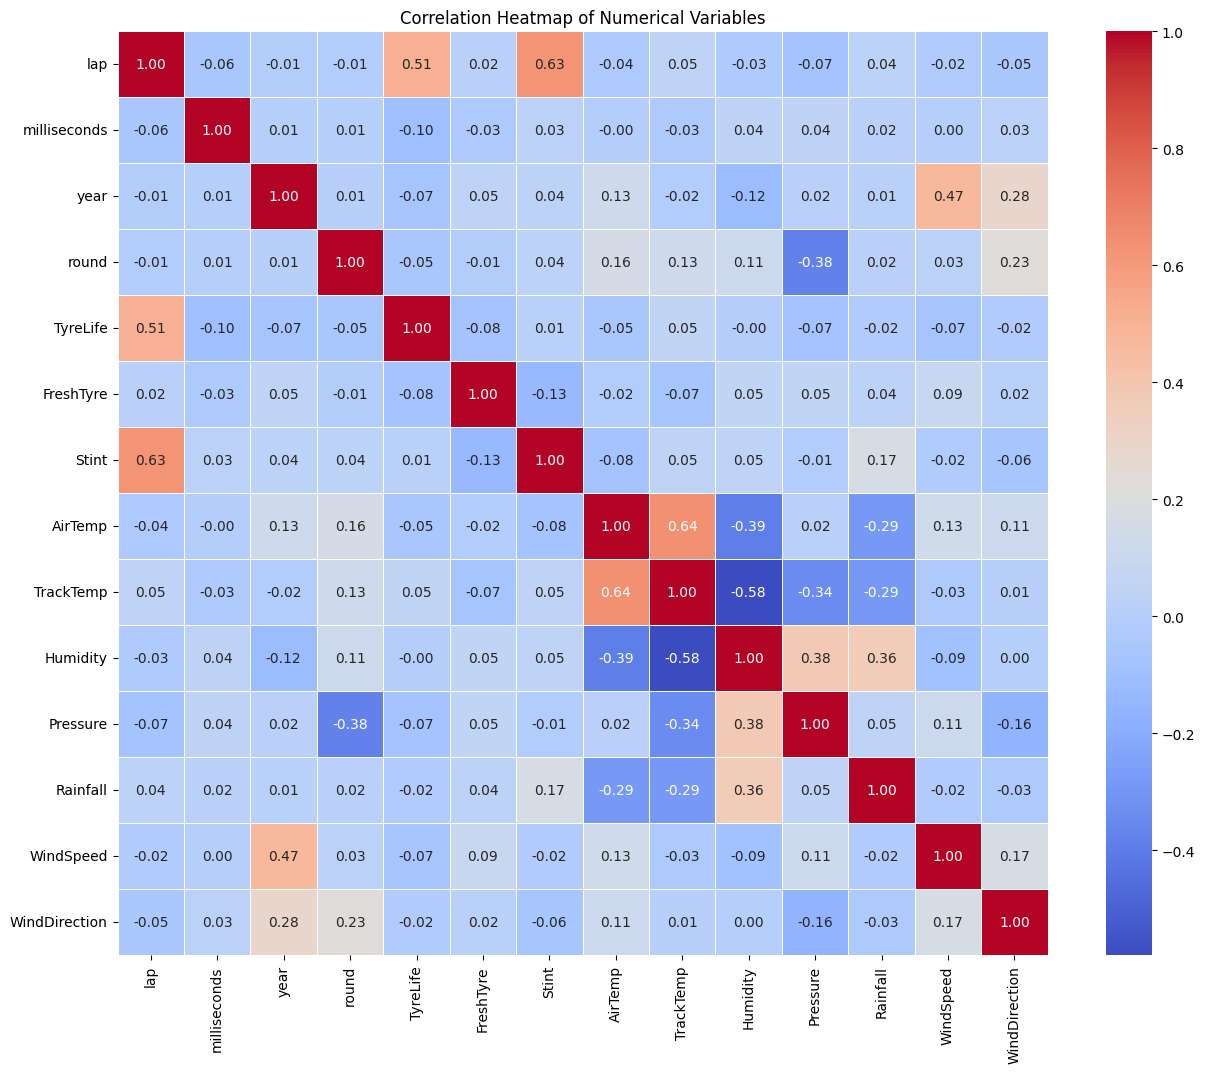

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
# Exclude 'code' and 'Compound' as they are object type and would need encoding for correlation
# But for a simple heatmap, focusing on numerical types is best.
numerical_df = df_treatment.select_dtypes(include=['number', 'bool']).drop(columns=['raceId', 'driverId','constructorId','circuitId'])

# Convert boolean to int for correlation calculation
numerical_df['FreshTyre'] = numerical_df['FreshTyre'].astype(int)

plt.figure(figsize=(15, 12))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Analisando o gráfico de calor de correlação, podemos observar uma correlação negativa fraca (aproximadamente -0.23) entre TyreLife (que representa a idade do pneu em voltas) e milliseconds (tempo de volta).
Essa correlação diz que, em média no dataset agregado, pneus mais velhos andam em voltas ligeiramente mais rápidas — o que parece contraintuitivo.
Uma explicação plausível é que pneus velhos aparecem mais em corridas secas com compostos duros (que já são mais lentos por natureza), enquanto pneus novos aparecem muito em relargadas após safety car ou trocas emergenciais, que produzem voltas atipicamente lentas.
A correlação captura esse padrão agregado, não a curva real de degradação de um pneu específico. Por isso, a relação verdadeira (pneu degrada → volta fica mais lenta) só apareceria se você filtrasse por composto e por stint, controlando esses confundidores.
É importante notar que correlações lineares podem não capturar a totalidade de uma relação não linear complexa, onde, em um certo ponto, a degradação dos pneus se tornaria mais significativa.

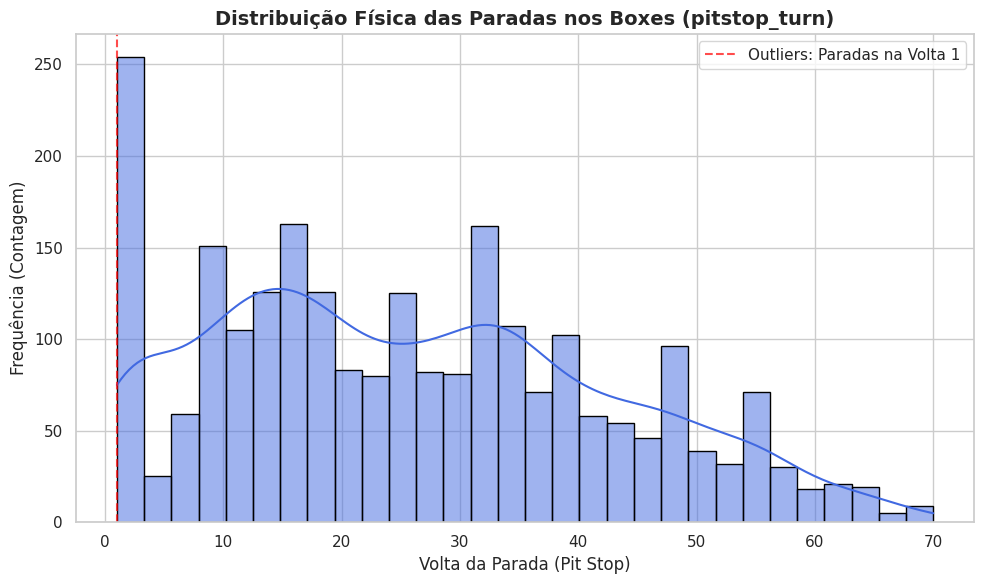

In [32]:
# Configurando o estilo do gráfico para o artigo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o histograma
sns.histplot(
    data=df_stops,
    x='pitstop_turn',
    kde=True,
    bins=30,
    color='royalblue',
    edgecolor='black'
)

# Customização técnica para a documentação/artigo
plt.title('Distribuição Física das Paradas nos Boxes (pitstop_turn)', fontsize=14, fontweight='bold')
plt.xlabel('Volta da Parada (Pit Stop)', fontsize=12)
plt.ylabel('Frequência (Contagem)', fontsize=12)

# Destacando potenciais outliers de volta 1 (Toques/Acidentes)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Outliers: Paradas na Volta 1')
plt.legend()

# Salvando a figura na pasta correta exigida pelo projeto (RQ-ER-01)
plt.tight_layout()
plt.show()

Para essa visão, a principal tarefa foi **identificar as voltas em que os pilotos realizaram paradas nos boxes**. Isso foi feito ao agrupar os dados por corrida (`raceId`), piloto (`driverId`) e `Stint` (período entre trocas de pneus). Ao encontrar a última volta (`lap`) de cada `stint` (excluindo o último stint da corrida, que não representa uma troca, mas sim o final da corrida), você criou uma nova coluna, `pitstop_turn`, que marca a volta exata onde ocorreu a troca de pneus. Essa é uma informação fundamental para entender a longevidade dos pneus e as estratégias de corrida. O dataframe `df_stops` agora contém essas informações sobre as paradas, sem considerar o último stint de cada piloto em cada corrida.

Em seguida, o `df_stops` foi utilizado para **visualizar a distribuição dessas voltas de pit stop** através de um histograma. Analisando o gráfico, podemos observar a frequência com que as paradas ocorrem em diferentes estágios da corrida. Isso nos ajuda a identificar padrões, como as voltas mais comuns para trocas de pneus, e até mesmo destacar anomalias, como paradas muito cedo (indicadas pela linha vermelha na volta 1, que podem sinalizar incidentes inesperados como toques ou acidentes). Essa visualização é essencial para compreender as estratégias típicas e atípicas de gerenciamento de pneus ao longo das corridas.

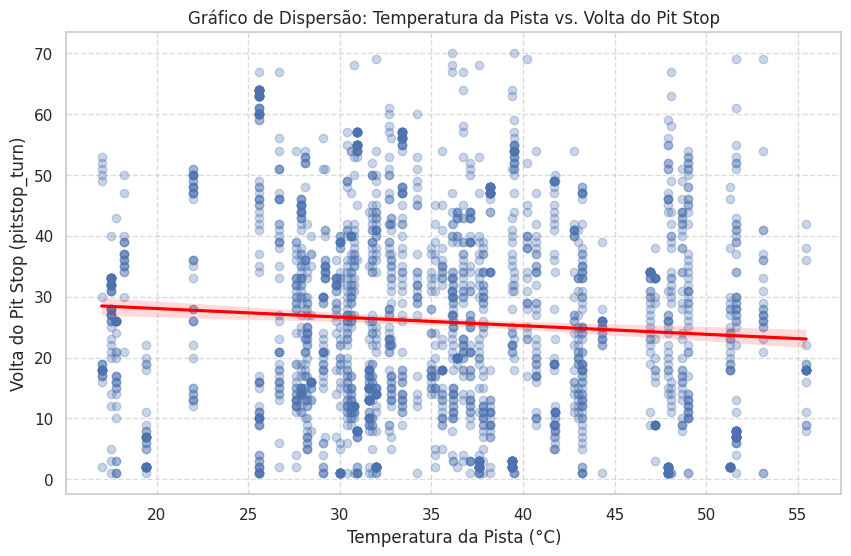

In [33]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x='TrackTemp', y='pitstop_turn',
    data=df_stops,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Gráfico de Dispersão: Temperatura da Pista vs. Volta do Pit Stop')
plt.xlabel('Temperatura da Pista (°C)')
plt.ylabel('Volta do Pit Stop (pitstop_turn)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Analisando o gráfico de dispersão entre temperatura da pista (`TrackTemp`) e a volta do pit stop (`pitstop_turn`), podemos observar a relação direta com a estratégia de troca de pneus. Pistas mais quentes tendem a degradar os compostos mais rapidamente, antecipando a parada, o que se manifestaria como uma tendência negativa na linha de regressão. Temperaturas moderadas permitem stints mais longos, postergando o pit stop. A dispersão considerável dos pontos indica que a temperatura é apenas um dos fatores: o composto utilizado e o circuito específico também exercem influência significativa.


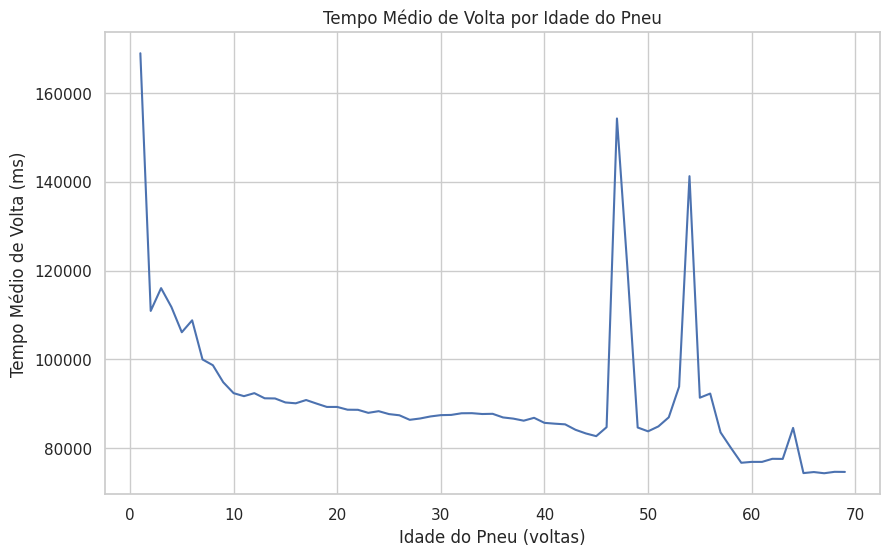

In [34]:
# CORRIGIDO: usar df_treatment (com TyreLife sem nulos) em vez do df bruto
media_pneu = (
    df_treatment.groupby('TyreLife')['milliseconds']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=media_pneu,
    x='TyreLife',
    y='milliseconds'
)
plt.title('Tempo Médio de Volta por Idade do Pneu')
plt.xlabel('Idade do Pneu (voltas)')
plt.ylabel('Tempo Médio de Volta (ms)')
plt.grid(True)
plt.show()


Analisando o gráfico, podemos observar uma tendência geral: conforme a idade do pneu aumenta, o tempo médio de volta tende a diminuir em um primeiro momento e depois se estabiliza. Isso sugere que, à medida que o pneu é usado, ele pode atingir um ponto ideal de temperatura e aderência que resulta em voltas mais rápidas. No entanto, após um certo número de voltas, a degradação do pneu provavelmente fará com que os tempos de volta voltem a aumentar, indicando que os pneus mais novos (com menor TyreLife) geralmente são mais rápidos, mas há um 'sweet spot' antes que a degradação se torne muito significativa.

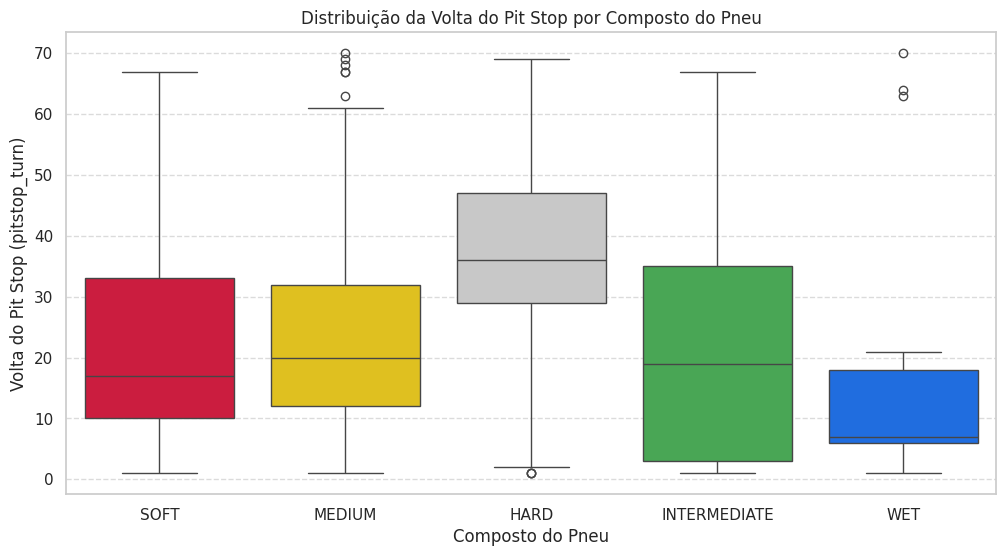

In [35]:
ordem_compostos = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
palette = {
    'SOFT': '#e8002d',
    'MEDIUM': '#ffd600',
    'HARD': '#c8c8c8',
    'INTERMEDIATE': '#39b54a',
    'WET': '#0067ff'
}

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Compound', y='pitstop_turn',
    data=df_stops_plot,
    order=ordem_compostos,
    palette=palette,
    hue='Compound', legend=False
)
plt.title('Distribuição da Volta do Pit Stop por Composto do Pneu')
plt.xlabel('Composto do Pneu')
plt.ylabel('Volta do Pit Stop (pitstop_turn)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


O boxplot confirma a hipótese central do projeto: compostos mais duros (HARD) apresentam medianas de `pitstop_turn` significativamente mais altas, indicando que os pilotos conseguem stints mais longos antes da parada. Compostos SOFT, por degradarem mais rapidamente, resultam em pit stops mais precoces e com maior variabilidade. INTERMEDIATE e WET apresentam distribuições atípicas pois seu uso depende das condições climáticas, não do desgaste convencional, o que os torna outliers estratégicos naturais nesse contexto. Essa separação clara entre compostos valida a inclusão de `Compound` como feature relevante para o modelo.


Preparação de Dados com Justificativas

# Preparação de Dados com Justificativas

## Divisão Treino-Teste

Os dados foram divididos em conjuntos de treinamento (80%) e teste (20%) utilizando a função train_test_split da biblioteca Scikit-Learn. A variável alvo definida foi pitstop_turn, que representa a volta em que ocorreu a parada nos boxes. A separação foi realizada antes de qualquer etapa de pré-processamento para evitar vazamento de dados (data leakage), garantindo que informações do conjunto de teste não influenciassem o treinamento dos modelos. Foi utilizado random_state=42 para assegurar a reprodutibilidade dos experimentos.

In [36]:
from sklearn.model_selection import train_test_split

y = df_stops['pitstop_turn']

# Remove alvo e colunas que causariam vazamento de informação
X = df_stops.drop(columns=['pitstop_turn','is_last_turn','raceId','driverId'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=== Dimensões ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Tipos das Colunas ===")
print(X_train.dtypes)

print("\n=== Valores Nulos ===")
print(X_train.isnull().sum())

print("\n=== Estatísticas da Variável Alvo ===")
print(y_train.describe())

=== Dimensões ===
X_train: (1920, 3)
X_test:  (480, 3)
y_train: (1920,)
y_test:  (480,)

=== Tipos das Colunas ===
Stint        float64
TrackTemp    float64
Compound         str
dtype: object

=== Valores Nulos ===
Stint        0
TrackTemp    0
Compound     0
dtype: int64

=== Estatísticas da Variável Alvo ===
count    1920.000000
mean       25.764063
std        16.716658
min         1.000000
25%        12.000000
50%        24.000000
75%        37.000000
max        70.000000
Name: pitstop_turn, dtype: float64


## Imputação de Nulos, Codificação Categórica e Padronização

Embora o planejamento inicial previsse a imputação de valores ausentes utilizando o SimpleImputer, a análise exploratória indicou que não havia valores nulos nas variáveis utilizadas pelo modelo. Ainda assim, a etapa foi mantida dentro do pipeline para garantir robustez e reprodutibilidade caso novos dados sejam incorporados futuramente. Para variáveis numéricas foi utilizado SimpleImputer(strategy='median'), enquanto para variáveis categóricas foi utilizado SimpleImputer(strategy='most_frequent').

A variável categórica Compound foi transformada por meio do OneHotEncoder(drop='first'), convertendo cada categoria em variáveis binárias. A remoção da primeira categoria evita a multicolinearidade perfeita, conhecida como dummy variable trap, especialmente relevante para modelos lineares.

As variáveis numéricas (Stint e TrackTemp) foram padronizadas utilizando o StandardScaler, que transforma os dados para média zero e desvio-padrão unitário. Os identificadores raceId e driverId foram excluídos das features para que o modelo generalize para corridas futuras, usando apenas informação disponível em tempo real.
Essa etapa é fundamental para modelos lineares regularizados, como Ridge e Lasso, pois impede que variáveis com escalas maiores exerçam influência desproporcional durante o treinamento e permite a comparação direta dos coeficientes estimados.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Colunas numéricas
num_features = [
    'Stint',
    'TrackTemp'
]

# Colunas categóricas
cat_features = [
    'Compound'
]

# Pipeline numérico
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Pré-processamento completo
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

print("Pipeline de pré-processamento criado com sucesso.")

Pipeline de pré-processamento criado com sucesso.


# Treinamento e Comparação Entre Modelos

Com o conjunto de dados devidamente preparado, foram treinados três modelos de regressão com o objetivo de prever a variável pitstop_turn, correspondente à volta em que ocorre a parada nos boxes.

A Regressão Linear foi utilizada como modelo baseline, servindo como referência inicial para avaliação do desempenho. Em seguida, foi aplicada a Regressão Ridge, que incorpora regularização L2 para reduzir a sensibilidade a multicolinearidade e melhorar a capacidade de generalização. Por fim, foi treinada a Regressão Lasso, que utiliza regularização L1 e possui a capacidade adicional de realizar seleção automática de variáveis ao reduzir coeficientes pouco relevantes para zero.

Todos os modelos foram encapsulados em pipelines juntamente com as etapas de pré-processamento definidas anteriormente, garantindo que a imputação, codificação categórica e padronização fossem aplicadas corretamente durante o treinamento.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression': {'model': LinearRegression(), 'params': {'alpha': 'N/A'}},
    'Ridge': {'model': Ridge(alpha=1.0),   'params': {'alpha': 1.0}},
    'Lasso': {'model': Lasso(alpha=0.1),   'params': {'alpha': 0.1}}
}

results = []

# Treinamento e Avaliação
for name, config in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    pipeline.fit(X_train, y_train)

    if name == 'Linear Regression':
      pipeline_final = pipeline

    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    results.append({
        'Modelo':        name,
        'alpha':         config['params']['alpha'],
        'RMSE Treino':   round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 3),
        'RMSE Teste':    round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),  3),
        'MAE Teste':     round(mean_absolute_error(y_test, y_pred_test), 3),
        'R² Teste':      round(r2_score(y_test, y_pred_test), 3)
    })


# Tabela de Resultados
results_df = pd.DataFrame(results).sort_values('RMSE Teste')
print(results_df)

              Modelo alpha  RMSE Treino  RMSE Teste  MAE Teste  R² Teste
0  Linear Regression   N/A       12.286      12.512      9.980     0.413
1              Ridge   1.0       12.286      12.514      9.978     0.412
2              Lasso   0.1       12.349      12.600     10.009     0.404


## Interpretação dos Resultados

Os três modelos apresentaram desempenhos bastante semelhantes na previsão da variável **pitstop_turn**. A Regressão Linear apresentou o menor valor de RMSE no teste (12.512 voltas), seguida muito de perto pela Regressão Ridge (12.514 voltas). A Regressão Lasso apresentou desempenho ligeiramente inferior, com RMSE de 12.600 voltas.

Em relação ao MAE (Mean Absolute Error), os três modelos apresentaram erro médio próximo de 10 voltas (Linear Regression: 9.980, Ridge: 9.978, Lasso: 10.009), indicando que, em média, a previsão da volta de parada difere aproximadamente dez voltas do valor real observado.

O coeficiente de determinação (R²) ficou em torno de 0.41 para a Regressão Linear (0.413) e Ridge (0.412), e 0.404 para o Lasso, indicando que aproximadamente 41% da variabilidade da volta de parada é explicada pelas variáveis utilizadas no estudo (`Stint`, `TrackTemp` e `Compound`). Esse resultado sugere que fatores adicionais não presentes no conjunto de dados provavelmente influenciam de forma significativa a estratégia de pit stop, tais como:

- Posição na corrida e gap para o carro à frente/atrás — a equipe para quando o undercut vale a pena, não quando o pneu acabou
- Safety car e bandeira vermelha — forçam paradas oportunistas que nenhuma feature climática prevê
- Número total de voltas da corrida — uma corrida de 50 voltas tem janela diferente de uma de 70
- Stint 1 vs. stint 2 — a decisão de parar depende de quantas paradas ainda faltam

Tudo isso é informação tática, que não está no dataset.

As diferenças observadas entre os modelos foram muito pequenas, indicando que a aplicação de regularização L1 (Lasso) ou L2 (Ridge) não trouxe ganhos expressivos em relação à Regressão Linear tradicional para o conjunto de atributos utilizado neste trabalho.

Considerando as métricas avaliadas, a **Regressão Linear** apresentou o melhor desempenho geral, obtendo simultaneamente o menor RMSE e o maior valor de R² no conjunto de teste. Dessa forma, ela foi selecionada como o modelo de referência para as etapas posteriores de validação e análise estatística.

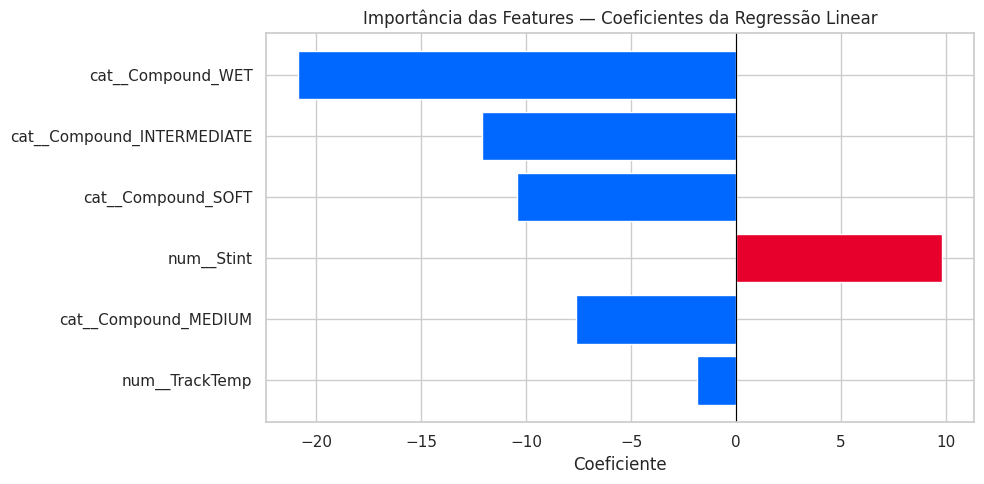

In [39]:
feature_names = pipeline_final.named_steps['preprocessor'].get_feature_names_out()
coeficientes  = pipeline_final.named_steps['model'].coef_

coef_df = (pd.DataFrame({'feature': feature_names, 'coeficiente': coeficientes})
             .reindex(pd.Series(coeficientes).abs().sort_values(ascending=False).index)
             .reset_index(drop=True))

plt.figure(figsize=(10, 5))
cores = ['#e8002d' if c > 0 else '#0067ff' for c in coef_df['coeficiente']]
plt.barh(coef_df['feature'], coef_df['coeficiente'], color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Importância das Features — Coeficientes da Regressão Linear')
plt.xlabel('Coeficiente')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Análise da Importância das Features

A análise dos coeficientes do modelo de Regressão Linear (`coef_df`) revela a seguinte hierarquia de influência sobre a `pitstop_turn`:

*   **`cat__Compound_WET` (coeficiente: -20.87):** Este é o coeficiente com maior magnitude negativa, indicando que o uso de pneus de chuva extrema (WET) está associado a paradas significativamente *mais precoces* (cerca de 20.87 voltas antes) em comparação com o composto base (pneu HARD, que foi a categoria descartada pelo `OneHotEncoder`). Isso é consistente com a estratégia de corrida, onde pneus WET são trocados rapidamente assim que a pista começa a secar.

*   **`cat__Compound_INTERMEDIATE` (coeficiente: -12.08) e `cat__Compound_SOFT` (coeficiente: -10.43):** Esses compostos também mostram uma forte associação com paradas mais cedo do que o pneu HARD, com o INTERMEDIATE antecipando a parada em cerca de 12.08 voltas e o SOFT em 10.43 voltas. Isso reflete a menor durabilidade e maior degradação desses compostos em comparação com o HARD, levando a stints mais curtos.

*   **`num__Stint` (coeficiente: 9.79):** Com um coeficiente positivo de 9.79, esta é a feature com maior influência positiva. Isso significa que, a cada incremento no número do stint, a `pitstop_turn` aumenta em aproximadamente 9.79 voltas. Esta é uma relação causal direta e esperada: quanto mais avançado o stint (e.g., segundo, terceiro stint), mais tarde na corrida a parada correspondente irá ocorrer.

*   **`cat__Compound_MEDIUM` (coeficiente: -7.65):** O pneu MEDIUM também contribui para paradas mais cedo do que o HARD, mas em menor grau que SOFT, INTERMEDIATE e WET, antecipando a parada em cerca de 7.65 voltas. Isso está em linha com a durabilidade intermediária deste composto.

*   **`num__TrackTemp` (coeficiente: -1.84):** A temperatura da pista apresenta um coeficiente negativo de -1.84. Isso implica que, a cada aumento de um grau Celsius na temperatura da pista, a `pitstop_turn` tende a ser antecipada em cerca de 1.84 voltas. Este resultado é logicamente consistente, pois temperaturas mais altas geralmente levam a uma maior degradação dos pneus, exigindo pit stops mais cedo.

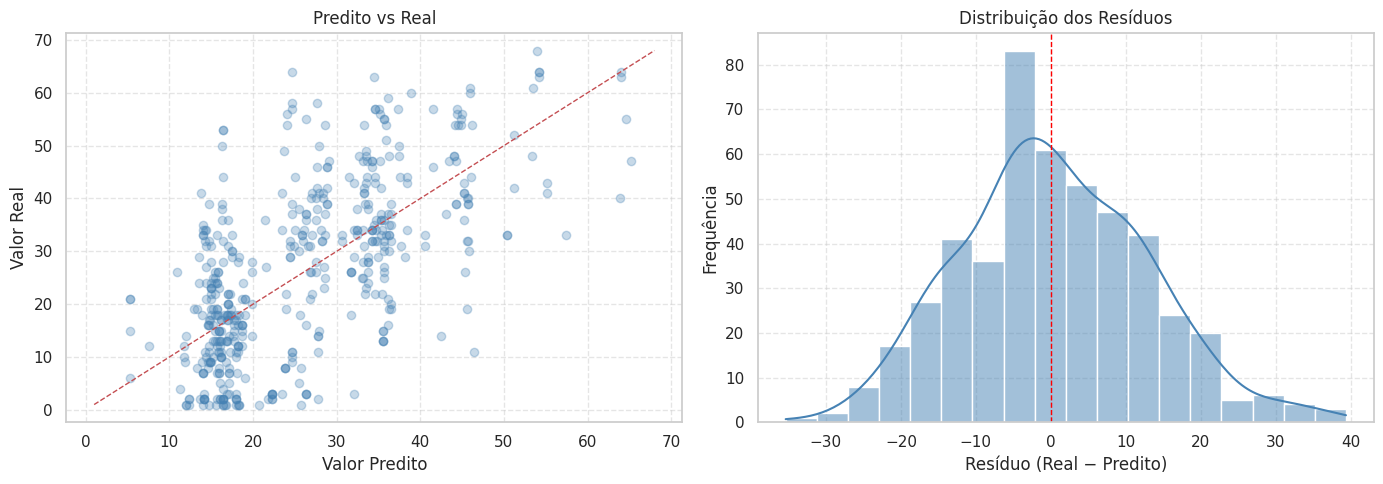

Resíduo médio:    0.424 voltas
Desvio-padrão:    12.518 voltas
Resíduo máximo:   39.4 voltas
Resíduo mínimo:   -35.4 voltas


In [40]:
y_pred_final = pipeline_final.predict(X_test)
residuos     = y_test - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predito vs Real
axes[0].scatter(y_pred_final, y_test, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1)
axes[0].set_xlabel('Valor Predito')
axes[0].set_ylabel('Valor Real')
axes[0].set_title('Predito vs Real')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Distribuição dos resíduos
sns.histplot(residuos, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Resíduo (Real − Predito)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Resíduo médio:    {residuos.mean():.3f} voltas")
print(f"Desvio-padrão:    {residuos.std():.3f} voltas")
print(f"Resíduo máximo:   {residuos.max():.1f} voltas")
print(f"Resíduo mínimo:   {residuos.min():.1f} voltas")

## Análise dos Gráficos: Predito vs Real e Distribuição dos Resíduos

### Gráfico 1: Predito vs Real

O gráfico de dispersão 'Predito vs Real' para a Regressão Linear no conjunto de teste revela que o modelo consegue capturar a tendência geral das voltas de pit stop, com os pontos se agrupando em torno da linha diagonal ideal. No entanto, há uma **dispersão notável dos pontos**, especialmente para valores mais altos de `pitstop_turn`. Isso indica que, embora o modelo não apresente um viés claro de superestimação ou subestimação consistentemente, ele tem **dificuldade em prever com precisão a volta exata do pit stop**, resultando em erros consideráveis para muitas observações. A ausência de um agrupamento mais denso perto da linha diagonal sugere que, apesar das features utilizadas, a variabilidade na decisão do pit stop ainda é alta.

### Gráfico 2: Distribuição dos Resíduos

A análise da distribuição dos resíduos fornece uma visão quantitativa dos erros do modelo:

*   **Resíduo médio: 0.424 voltas:** O valor médio dos resíduos está próximo de zero, o que é um bom indicativo de que o modelo não possui um **viés sistemático** (ou seja, não está consistentemente superestimando ou subestimando a `pitstop_turn`).

*   **Desvio-padrão: 12.518 voltas:** Este valor elevado (12.518 voltas) indica uma **grande variabilidade nos erros de previsão**. Mesmo com um viés médio baixo, os erros individuais podem ser substanciais. Este resultado quantifica a dispersão observada no gráfico 'Predito vs Real'.

*   **Resíduo máximo: 39.4 voltas:** O maior erro de subestimação foi de 39.4 voltas, significando que o modelo previu um pit stop 39.4 voltas *antes* do que realmente aconteceu. Isso aponta para falhas significativas em cenários específicos.

*   **Resíduo mínimo: -35.4 voltas:** O maior erro de superestimação foi de -35.4 voltas, indicando que o modelo previu um pit stop 35.4 voltas *depois* do que realmente ocorreu. Isso também destaca a ocorrência de erros substanciais em outra direção.

**Conclusão dos Resultados:** Os resultados combinados mostram que a Regressão Linear, embora seja um bom ponto de partida com baixo viés médio, tem uma **capacidade limitada de prever com alta precisão a `pitstop_turn`**, conforme evidenciado pela alta variabilidade dos resíduos e pela dispersão no gráfico predito vs. real. A presença de resíduos máximos e mínimos tão distantes de zero reforça a hipótese de que fatores táticos e inesperados, não capturados pelas features atuais, desempenham um papel crucial na determinação do momento do pit stop.

# Validação Cruzada com Média e Desvio-Padrão

A avaliação realizada no tópico anterior utilizou apenas uma divisão treino-teste. Embora essa abordagem forneça uma estimativa inicial do desempenho dos modelos, os resultados podem variar dependendo da forma como os dados são particionados. Para obter uma avaliação mais robusta e reduzir a influência de uma divisão específica dos dados, foi utilizada a técnica de Validação Cruzada K-Fold.

Neste trabalho foi adotado um esquema de 10 folds, no qual os dados de treinamento são divididos em dez subconjuntos. A cada iteração, nove subconjuntos são utilizados para treinamento e um para validação, até que todos os subconjuntos tenham sido utilizados como validação exatamente uma vez.

A métrica principal utilizada foi o RMSE (Root Mean Squared Error), calculando-se posteriormente a média e o desvio-padrão dos resultados obtidos nos dez folds. Dessa forma, os modelos podem ser comparados não apenas pelo desempenho médio, mas também pela estabilidade dos resultados.

In [41]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Configuração da Validação Cruzada
kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

results_cv = []

# Cross Validation
for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )

    rmse_scores = -scores

    results_cv.append([
        name,
        rmse_scores.mean(),
        rmse_scores.std()
    ])

# Resultados
cv_results_df = pd.DataFrame(
    results_cv,
    columns=['Modelo', 'RMSE Médio', 'Desvio-Padrão']
)

cv_results_df = cv_results_df.sort_values('RMSE Médio')

print(cv_results_df)

              Modelo  RMSE Médio  Desvio-Padrão
0  Linear Regression   12.325993       0.601183
1              Ridge   12.326127       0.600313
2              Lasso   12.390713       0.584566


## Validação Cruzada com Média e Desvio-Padrão

Para obter uma estimativa mais robusta do desempenho dos modelos, foi utilizada a técnica de Validação Cruzada K-Fold com dez partições (*10-Fold Cross Validation*). Nessa abordagem, os dados de treinamento são divididos em dez subconjuntos, sendo que a cada iteração nove subconjuntos são utilizados para treinamento e um para validação. Ao final, cada subconjunto é utilizado exatamente uma vez como conjunto de validação.

A métrica principal adotada foi o **RMSE (Root Mean Squared Error)**. Para cada modelo foram calculados a média ($\\mu$) e o desvio-padrão ($\\sigma$) dos resultados obtidos nos dez folds.

| Modelo            | RMSE Médio ($\\mu$) | Desvio-Padrão ($\\sigma$) |
| ----------------- | -----------------: | -----------------------: |
| Linear Regression |             12.326 |                    0.601 |
| Ridge             |             12.326 |                    0.600 |
| Lasso             |             12.391 |                    0.585 |

## Interpretação dos Resultados

Os resultados obtidos pela validação cruzada reforçam as conclusões observadas anteriormente no conjunto de teste. A Regressão Linear apresentou o menor RMSE médio (12,326), seguida de forma praticamente idêntica pela Regressão Ridge (12,326). A diferença entre ambos os modelos foi inferior a uma centésimo de volta (0.00013 voltas), indicando desempenho praticamente equivalente.

A Regressão Lasso apresentou RMSE médio ligeiramente superior (12,391), sugerindo uma pequena perda de desempenho em comparação aos demais modelos. Entretanto, o desvio-padrão observado para todos os modelos permaneceu abaixo de 0,60 volta, demonstrando elevada estabilidade dos resultados entre os diferentes folds.

Os valores obtidos indicam que os modelos possuem comportamento consistente independentemente da divisão dos dados utilizada durante a validação. Além disso, as diferenças extremamente pequenas entre Regressão Linear e Ridge sugerem que a regularização L2 não trouxe benefícios significativos para o conjunto de atributos empregado neste estudo.

Com base nos resultados da validação cruzada, a Regressão Linear e a Regressão Ridge podem ser consideradas equivalentes em termos de desempenho preditivo, enquanto a Regressão Lasso apresentou desempenho ligeiramente inferior.

# Teste Estatístico entre Modelos Candidatos

Embora a validação cruzada tenha mostrado pequenas diferenças entre os modelos avaliados, uma diferença na média do RMSE não é suficiente para afirmar que um modelo é realmente superior aos demais. Para verificar se as diferenças observadas são estatisticamente significativas, foi utilizado o Teste de Wilcoxon Signed-Rank.

O teste de Wilcoxon é um teste não paramétrico adequado para comparações pareadas, pois não exige que as diferenças entre os erros dos modelos sigam uma distribuição normal. Como todos os modelos foram avaliados exatamente nos mesmos folds da validação cruzada, seus resultados podem ser comparados de forma pareada.

Neste estudo, foi adotado um nível de significância de 5% ($\alpha = 0,05$). Assim:

Se p < 0,05, rejeita-se a hipótese nula e conclui-se que existe diferença estatisticamente significativa entre os modelos.
Se p ≥ 0,05, não há evidências suficientes para afirmar que um modelo supera o outro.

In [42]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from scipy.stats import wilcoxon

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

# RMSE por fold
linear_scores = -cross_val_score(
    pipeline_linear,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

ridge_scores = -cross_val_score(
    pipeline_ridge,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

lasso_scores = -cross_val_score(
    pipeline_lasso,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

# Testes de Wilcoxon
stat_lr_ridge, p_lr_ridge = wilcoxon(
    linear_scores,
    ridge_scores
)

stat_lr_lasso, p_lr_lasso = wilcoxon(
    linear_scores,
    lasso_scores
)

stat_ridge_lasso, p_ridge_lasso = wilcoxon(
    ridge_scores,
    lasso_scores
)

print("Linear vs Ridge")
print(f"p-value = {p_lr_ridge:.6f}")

print("\nLinear vs Lasso")
print(f"p-value = {p_lr_lasso:.6f}")

print("\nRidge vs Lasso")
print(f"p-value = {p_ridge_lasso:.6f}")

Linear vs Ridge
p-value = 1.000000

Linear vs Lasso
p-value = 0.027344

Ridge vs Lasso
p-value = 0.019531


## Resultados do Teste de Wilcoxon

| Comparação              | p-value |
|-------------------------|---------|
| Linear Regression vs Ridge | 1.0000  |
| Linear Regression vs Lasso | 0.0273  |
| Ridge vs Lasso          | 0.0195  |

## Interpretação dos Resultados

Os resultados do teste de Wilcoxon indicam que, com um nível de significância de 5% ($\alpha = 0,05$):

*   **Linear Regression vs Ridge (p = 1.0000):** O valor-p é maior que 0.05, o que significa que não há evidências estatisticamente significativas para afirmar que a Regressão Linear é superior ou inferior à Regressão Ridge. Ambos os modelos podem ser considerados estatisticamente equivalentes.

*   **Linear Regression vs Lasso (p = 0.0273):** O valor-p é menor que 0.05, indicando que existe uma diferença estatisticamente significativa no desempenho entre a Regressão Linear e a Regressão Lasso. Como a Regressão Linear teve um RMSE médio menor, pode-se inferir que ela performa melhor que o Lasso para este dataset.

*   **Ridge vs Lasso (p = 0.0195):** Similarmente, o valor-p é menor que 0.05, demonstrando uma diferença estatisticamente significativa entre a Regressão Ridge e a Regressão Lasso. A Regressão Ridge, com seu RMSE médio ligeiramente menor, é estatisticamente superior ao Lasso.

Em resumo, a Regressão Linear e a Regressão Ridge são estatisticamente equivalentes e apresentaram desempenho superior ao modelo Lasso para a tarefa de prever a volta do pit stop. Considerando a menor complexidade computacional e interpretativa, a **Regressão Linear** permanece como o modelo final selecionado para este estudo.